In [1]:
import sys
import os

import os
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# Model Registry & Architecture
from registry.model_registry import MODEL_REGISTRY
from models import segFormer, STANet, swin_earlyfusion, BIT, Gswin_tac, UNet

# Dataset & Preprocessing
from datasets.dataLoader import create_dataloaders
from utils.preprocess import preprocess_to_npy

# 🔥 UPDATED LOSS FUNCTIONS 
from loss.ce_dice_loss import FocalDiceCELoss
from loss.boundary_loss import DeforestationTotalLoss


# Evaluation Metrics
from evaluation.metrics import compute_confusion_matrix, evaluate_all
from evaluation.evaluate import evaluate_model

# Utils & Configs
from configs import train_config as config
from utils.forward_model import forward_model
from logs.logger import Logger
# from utils.preProcessPatch750 import compute_patch_stats,select_750_with_pixel_ratio
from tqdm import tqdm
import shutil
# from utils.preProcessPatch5000 import compute_patch_stats,select_5000_with_30_percent_ratio





/Users/macbook/Documents/Binus/Research Track/Codes/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. Training modular code

In [ ]:
import torch
from torch.cuda.amp import autocast, GradScaler
import os

def train_model(
    model,
    train_loader,
    val_loader,
    config,
    criterion,
    optimizer,
    model_type,
    scheduler,
    device,
    logger
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)
    scaler = GradScaler()

    # =============================================================
    # MODIFIKASI: RESUME DARI BEST MODEL (FINE-TUNING)
    # =============================================================
    checkpoint_path = os.path.join(config.checkpoint_dir, f"{config.model_name}_best.pth")
    best_miou = 0
    start_epoch = 0

    if os.path.exists(checkpoint_path):
        print(f"\n🔄 [RESUME] Memuat weights terbaik dari: {checkpoint_path}")
        # Load state dict
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint)
        
        # Penyesuaian untuk Fine-Tuning: Turunkan LR 10x lipat
        # Misal dari 1e-4 menjadi 1e-5 agar tidak "Yo-Yo" lagi
        for param_group in optimizer.param_groups:
            new_lr = param_group['lr'] * 0.1 
            param_group['lr'] = new_lr
            print(f"📉 [FINE-TUNING] Learning Rate diturunkan ke: {new_lr:.2e}")
        
        # Kamu bisa set manual start_epoch jika ingin log-nya lanjut (misal: 19)
        # start_epoch = 19 
    else:
        print("\n⚠️ [START] Checkpoint tidak ditemukan. Memulai training dari nol.")

    os.makedirs(config.checkpoint_dir, exist_ok=True)

    # Mulai Loop Training
    for epoch in range(start_epoch, config.num_epochs):
        print(f"\n===== Epoch {epoch+1}/{config.num_epochs} =====")

        # ===============================
        # TRAIN PHASE
        # ===============================
        model.train()
        train_loss = 0
        epoch_loss_details = {"ce": 0, "focal": 0, "dice": 0, "boundary": 0}
        num_batches = 0

        for t1, t2, mask, file_id in train_loader:
            t1, t2, mask = t1.to(device), t2.to(device), mask.to(device)

            optimizer.zero_grad()

            with autocast():
                pred = forward_model(model, t1, t2, model_type)
                loss, loss_details = criterion(pred, mask)

            if not torch.isfinite(loss):
                print(f"❌ Invalid loss detected in: {file_id}")
                continue # Skip batch bermasalah daripada crash

            scaler.scale(loss).backward()

            # Gradient Clipping: Menjaga stabilitas pada RTX 3080
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            for key in epoch_loss_details:
                if key in loss_details:
                    epoch_loss_details[key] += loss_details[key]
            num_batches += 1

        train_loss /= num_batches
        for key in epoch_loss_details:
            epoch_loss_details[key] /= num_batches

        print(f"Train Loss: {train_loss:.4f} (Focal: {epoch_loss_details['focal']:.4f}, Dice: {epoch_loss_details['dice']:.4f})")

        # ===============================
        # VALIDATION PHASE
        # ===============================
        model.eval()
        val_loss = 0
        num_val_batches = 0
        conf_matrix = torch.zeros((config.num_classes, config.num_classes)).to(device)
        
        with torch.no_grad():
            for t1, t2, mask, file_id in val_loader:
                t1, t2, mask = t1.to(device), t2.to(device), mask.to(device)

                with autocast():
                    pred = forward_model(model, t1, t2, model_type)
                    loss, _ = criterion(pred, mask)

                val_loss += loss.item()
                num_val_batches += 1

                pred_label = torch.argmax(pred, dim=1)
                conf_matrix += compute_confusion_matrix(pred_label, mask, config.num_classes)

        val_loss /= num_val_batches

        # ===============================
        # METRICS CALCULATION
        # ===============================
        results = evaluate_all(conf_matrix)
        miou = results.get("iou", 0) 
        iou_per_class = results.get("_iou_per_class", [0, 0, 0]) 

        metrics = {
            "iou": miou,
            "f1": results.get("f1", 0),
            "precision": results.get("precision", 0),
            "recall": results.get("recall", 0),
            "accuracy": results.get("accuracy", 0)
        }

        if logger:
            logger.log(epoch=epoch + 1, train_loss=train_loss, val_loss=val_loss, metrics=metrics)
            logger.print(epoch=epoch + 1, train_loss=train_loss, val_loss=val_loss, metrics=metrics)
            
            print(f"   > IoU per Class:")
            print(f"     [0 - No Change]: {iou_per_class[0]:.4f}")
            print(f"     [1 - Deforest ]: {iou_per_class[1]:.4f}")
            print(f"     [2 - Forest   ]: {iou_per_class[2]:.4f}")
            print(f"   > Detail Loss: CE: {epoch_loss_details['ce']:.4f} | Focal: {epoch_loss_details['focal']:.4f} | Dice: {epoch_loss_details['dice']:.4f}")

        # ===============================
        # SCHEDULER & SAVING
        # ===============================
        if scheduler:
            try:
                scheduler.step(val_loss) 
            except:
                scheduler.step()

        if miou > best_miou:
            best_miou = miou
            if config.save_model:
                path = os.path.join(config.checkpoint_dir, f"{config.model_name}_best.pth")
                torch.save(model.state_dict(), path)
                print(f"⭐ New Best mIoU: {best_miou:.4f}. Model updated!")

    print("\n✅ Training finished.")

Preprocess 750 patches

In [ ]:
# root_dir = "data/"
# # cell 1 (sekali saja)
# preprocess_to_npy(root_dir=root_dir)

# --- KONFIGURASI PATH ---
root_dir = "data/"
cache_dir_asli = "data/cache_npy"
cache_dir_output = "data/cache_npy_output"

# 1. Preprocess Awal (26.000 file TIFF -> NPZ)
# Pastikan fungsi ini sudah kamu jalankan atau definisikan sebelumnya
if not os.path.exists(cache_dir_asli):
    print("🚀 Menjalankan preprocess awal ke NPZ...")
    preprocess_to_npy(root_dir=root_dir)
else:
    print(f"✅ Folder {cache_dir_asli} sudah ada.")

# 2. Hitung Statistik (Proses yang memakan waktu lama)
stats = compute_patch_stats(cache_dir_asli)

# 3. Seleksi 750 Patch Terbaik (Target Pixel Ratio 10%)
selected_ids = select_750_with_pixel_ratio(stats, target_ratio=0.1, total_patches=750)

# 4. Penyalinan Fisik & Pembuatan Metadata (IDs & Labels)
print(f"\n📂 Menyalin file terpilih & sinkronisasi metadata ke {cache_dir_output}...")
os.makedirs(cache_dir_output, exist_ok=True)

new_ids_list = []
new_labels_list = [] # <--- Tambahan untuk labels.npy

# Buat dictionary agar ambil info c1, c2 cepat tanpa load file lagi
stats_dict = {s['id']: s for s in stats}

for file_id in tqdm(selected_ids):
    file_npz = file_id.replace(".tif", ".npz")
    src = os.path.join(cache_dir_asli, file_npz)
    dst = os.path.join(cache_dir_output, file_npz)
    
    if os.path.exists(src):
        # A. Salin file fisik
        shutil.copy(src, dst)
        
        # B. Simpan ID
        new_ids_list.append(file_id)
        
        # C. Tentukan Label Ringkasan (1: Ada Perubahan, 0: Tidak Ada)
        # Diambil dari data stats yang sudah dihitung di Langkah 2
        s_info = stats_dict[file_id]
        has_change = 1 if (s_info['c1'] > 0 or s_info['c2'] > 0) else 0
        new_labels_list.append(has_change)

# 5. Simpan file metadata agar DataLoader bisa baca secara mandiri
np.save(os.path.join(cache_dir_output, "ids.npy"), np.array(new_ids_list))
np.save(os.path.join(cache_dir_output, "labels.npy"), np.array(new_labels_list))

print(f"\n✨ SELESAI! Folder '{cache_dir_output}' siap digunakan.")
print(f"Total file: {len(new_ids_list)} | IDs: OK | Labels: OK")

PreProcess 5000 patches

In [ ]:
# --- CONFIG PATH ---
cache_dir_asli = "data/cache_npy"
cache_dir_output = "data/cache_npy_output" # Nama folder tetap sama
os.makedirs(cache_dir_output, exist_ok=True)

# A. Ambil Statistik (Gunakan stats_data yang sudah ada di memori jika cell sebelumnya sudah run)
stats_data = compute_patch_stats(cache_dir_asli)

# B. Seleksi 5000 Patch Terbaik (Rasio 0.3)
selected_items = select_5000_with_30_percent_ratio(stats_data, target_ratio=0.3, total_patches=5000)

# C. Salin File & Buat Metadata Sinkron
print(f"\n📂 Tahap Akhir: Menyalin 5000 file ke {cache_dir_output}...")
new_ids = []
new_labels = []

for item in tqdm(selected_items):
    file_id = item["id"]
    file_npz = file_id.replace(".tif", ".npz")
    
    src = os.path.join(cache_dir_asli, file_npz)
    dst = os.path.join(cache_dir_output, file_npz)
    
    if os.path.exists(src):
        shutil.copy(src, dst)
        new_ids.append(file_id)
        
        # Label 1 jika ada pixel perubahan (c1 atau c2 > 0)
        label = 1 if (item["c1"] > 0 or item["c2"] > 0) else 0
        new_labels.append(label)

# D. Save Metadata (Overwriting metadata lama)
np.save(os.path.join(cache_dir_output, "ids.npy"), np.array(new_ids))
np.save(os.path.join(cache_dir_output, "labels.npy"), np.array(new_labels))

print(f"\n✨ PROSES SELESAI!")
print(f"Kini folder '{cache_dir_output}' berisi 5000 patches terpilih.")

2. Init DataLoader

In [3]:
root_dir = "data/"

train_loader, val_loader, test_loader = create_dataloaders(
    root_dir=root_dir,
    batch_size=config.TrainConfig.batch_size
)

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

75
10
10


CHECKING DATALOADER

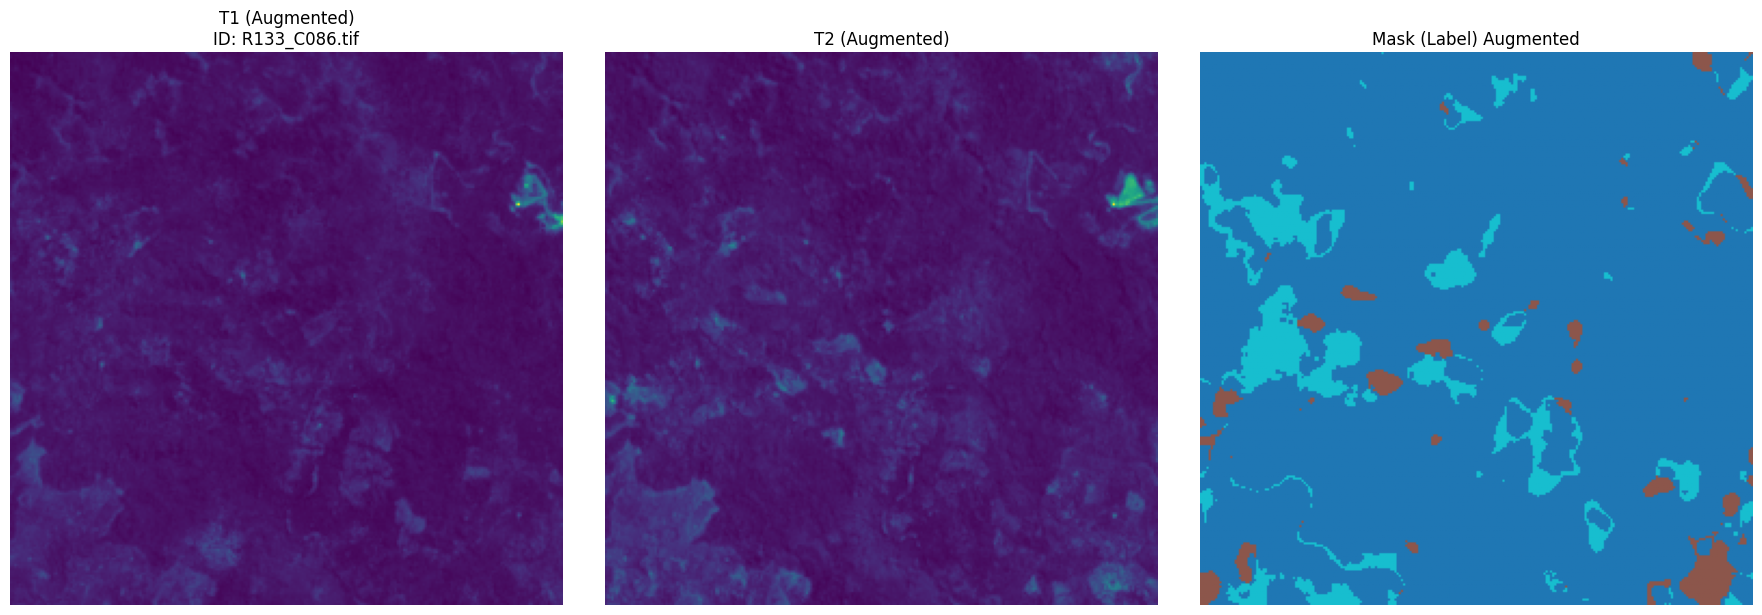

Bentuk Tensor T1: torch.Size([8, 10, 256, 256])
Nilai unik di Mask: [0 1 2]


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Ambil satu batch contoh dari train_loader
# t1: [Batch, Channel, H, W], t2: [Batch, Channel, H, W], mask: [Batch, H, W]
t1, t2, mask, file_ids = next(iter(train_loader))

# 2. Pilih index pertama dari batch tersebut
idx = 0
img_t1 = t1[idx][0].cpu().numpy() # Ambil Band 1 dari T1
img_t2 = t2[idx][0].cpu().numpy() # Ambil Band 1 dari T2
img_mask = mask[idx].cpu().numpy()

# 3. Plot untuk Verifikasi
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img_t1, cmap='viridis')
ax[0].set_title(f"T1 (Augmented)\nID: {file_ids[idx]}")
ax[0].axis('off')

ax[1].imshow(img_t2, cmap='viridis')
ax[1].set_title("T2 (Augmented)")
ax[1].axis('off')

# Gunakan cmap 'tab10' atau 'jet' agar perbedaan kelas (0, 1, 2) terlihat jelas
ax[2].imshow(img_mask, cmap='tab10') 
ax[2].set_title("Mask (Label) Augmented")
ax[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Bentuk Tensor T1: {t1.shape}")
print(f"Nilai unik di Mask: {np.unique(img_mask)}")

3. Init parameters

In [ ]:
# ====================================
# HITUNG CLASS WEIGHT (DARI TRAIN LABEL)
# ====================================
cache_dir = os.path.join(root_dir, "cache_npy_output")
labels = np.load(os.path.join(cache_dir, "labels.npy"))

indices = np.arange(len(labels))

train_idx, temp_idx, train_labels, temp_labels = train_test_split(
    indices, labels, test_size=0.2, stratify=labels, random_state=42
)

# 🔥 Class weight otomatis (Raw Inverse Frequency)
ids = np.load(os.path.join(cache_dir, "ids.npy"))
num_classes = 3
class_counts = np.zeros(num_classes)

for idx in train_idx:
    file_id = ids[idx]
    npy_path = os.path.join(cache_dir, file_id.replace(".tif", ".npz"))
    data = np.load(npy_path)
    mask = data["mask"]

    for c in range(num_classes):
        # Menghitung pixel per kelas (Ignore index -1 tidak dihitung)
        class_counts[c] += (mask == c).sum()

# Normalisasi agar kelas terkecil tidak menyebabkan bobot terlalu raksasa sebelum smoothing
class_counts[class_counts == 0] = 1
total_pixels = class_counts.sum()
# Gunakan Raw Inverse Frequency (Tanpa sqrt di sini, karena sqrt dilakukan di dalam class Loss)
raw_weights = total_pixels / (num_classes * class_counts)
raw_weights = torch.tensor(raw_weights, dtype=torch.float32).to(config.TrainConfig.device)

# ====================================
# LOSS (MENGGUNAKAN UPDATE TERBARU)
# ====================================
# 1. Untuk model baseline (U-Net EF) menggunakan Focal + Dice + CE
criterion_model = FocalDiceCELoss(
    raw_weights=raw_weights,
    ce_weight=0.5,      # Sesuai diskusi: CE sebagai anchor unweighted (0.5)
    focal_weight=1.0, 
    dice_weight=1.0
)

# 2. Untuk model riset (GSwinT AC) menggunakan versi lengkap (dengan Boundary)
criterion_gswintac = DeforestationTotalLoss(  
    raw_weights=raw_weights,
    ce_weight=0.5,
    focal_weight=1.0,
    dice_weight=1.0,
    boundary_weight=0.5 # Sesuai diskusi: 0.5 agar tidak terlalu mendominasi
)

# ====================================
# MODEL & OPTIMIZER (TIDAK BERUBAH)
# ====================================
model_info = MODEL_REGISTRY["unet_ef"]
model = model_info["model"]()
model.to(config.TrainConfig.device) # Pastikan model masuk ke device
model_type = model_info["type"]
optimizer_name = model_info["optimizer"]

if optimizer_name == "Adam":
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config.TrainConfig.learning_rate
    )
elif optimizer_name == "AdamW":
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.TrainConfig.learning_rate,
        weight_decay=config.TrainConfig.weight_decay
    )

# ====================================
# SCHEDULER (SANGAT DISARANKAN UNTUK HYBRID LOSS)
# ====================================
scheduler = None
if config.TrainConfig.scheduler == "cosine":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config.TrainConfig.t_max
    )
# Tambahan: Scheduler ini sangat membantu menjaga stabilitas saat Dice & Focal berinteraksi

4. Train the models ( makesure to change model_name in config first )

In [6]:
# ====================================
# SELEKSI CRITERION (LOSS FUNCTION)
# ====================================
if config.TrainConfig.model_name != "gswin_tac":
    # Gunakan loss standar (tanpa boundary) untuk baseline
    criterion = criterion_model 
else: 
    # Gunakan loss riset lengkap (Boundary + GCN support) untuk G.S.T.T.C.A
    criterion = criterion_gswintac

# Inisialisasi Logger (WandB/Tensorboard)
logger = Logger()

# ====================================
# MULAI TRAINING LOOP
# ====================================
# train_loader sekarang sudah otomatis melakukan augmentasi on-the-fly
# val_loader tetap memberikan data original untuk validasi yang jujur
train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=config.TrainConfig,
    criterion=criterion,
    optimizer=optimizer,
    model_type=model_type,
    scheduler=scheduler,
    device=config.TrainConfig.device,
    logger=logger
)

/var/folders/y4/8wf9ymkn149fmgb1hgtj41200000gn/T/ipykernel_2197/4223946727.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/var/folders/y4/8wf9ymkn149fmgb1hgtj41200000gn/T/ipykernel_2197/4223946727.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



===== Epoch 1/30 =====
Train Loss: 1.4062 (Focal: 0.1122, Dice: 0.8480)


/var/folders/y4/8wf9ymkn149fmgb1hgtj41200000gn/T/ipykernel_2197/4223946727.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 1
Train Loss : 1.4062
Val Loss   : 1.4137
IOU       : 0.2966
F1        : 0.3139
PRECISION : 0.2966
RECALL    : 0.3333
ACCURACY  : 0.8897
   > IoU per Class:
     [Class 0 - No Change]: 0.8897
     [Class 1 - Deforest ]: 0.0000
     [Class 2 - Forest   ]: 0.0000
   > Detail Loss: CE: 0.8921 | Focal: 0.1122 | Dice: 0.8480
New Best mIoU: 0.2966. Model saved!

===== Epoch 2/30 =====


/var/folders/y4/8wf9ymkn149fmgb1hgtj41200000gn/T/ipykernel_2197/4223946727.py:146: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_loss) # Untuk ReduceLROnPlateau


Train Loss: 1.3910 (Focal: 0.1110, Dice: 0.8452)

Epoch 2
Train Loss : 1.3910
Val Loss   : 1.4025
IOU       : 0.2966
F1        : 0.3139
PRECISION : 0.2966
RECALL    : 0.3333
ACCURACY  : 0.8897
   > IoU per Class:
     [Class 0 - No Change]: 0.8897
     [Class 1 - Deforest ]: 0.0000
     [Class 2 - Forest   ]: 0.0000
   > Detail Loss: CE: 0.8697 | Focal: 0.1110 | Dice: 0.8452

===== Epoch 3/30 =====


KeyboardInterrupt: 

5. TEST the models 

In [ ]:
model_path = os.path.join(
    config.TrainConfig.checkpoint_dir,
    f"{config.TrainConfig.model_name}_best.pth"
)

evaluate_model(
    model=model,
    loader=test_loader,
    model_path=model_path,
    num_classes=config.TrainConfig.num_classes,
    model_type=model_type,
    device=config.TrainConfig.device
)